In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import sklearn.metrics
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.sparse as sp
from torch.optim import Adam
import torch.utils.data as Data
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from collections import Counter
import copy
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns 

# ================== 设置随机种子以确保结果可复现 ==================
def set_seed(seed=42):
    """
    设置所有随机种子以确保实验结果可复现
    
    参数:
        seed: 随机种子值，默认42
    """
    random.seed(seed)                      # Python随机数生成器
    np.random.seed(seed)                   # NumPy随机数生成器
    torch.manual_seed(seed)                # PyTorch CPU随机数生成器
    torch.cuda.manual_seed(seed)           # PyTorch单GPU随机数生成器
    torch.cuda.manual_seed_all(seed)       # PyTorch多GPU随机数生成器
    
    # 确保CUDA操作的确定性（可能会影响性能）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    
    print(f"✓ 已设置随机种子: {seed}")

# 在导入后立即设置随机种子
set_seed(42)


✓ 已设置随机种子: 42


In [ ]:
'''
# ================== 模态选择 ==================
# 'multi' : RNA + ADT
# 'rna'   : 仅RNA
# 'adt'   : 仅ADT
MODALITY = 'multi'    # ← 在此切换: 'multi' / 'rna' / 'adt'



#================== 数据格式与数据集配置 ==================
# 切换读取模式：
#   'mtx'  → 原始格式（matrix.mtx + features.tsv + ADT.csv + label.csv）
#   'h5ad' → 新格式（rna.h5ad + adt.h5ad + label.csv）
DATA_FORMAT = 'mtx'   # ← 在此切换: 'mtx' 或 'h5ad'
DATASET_ID  = 9       # ← 在此切换数据集编号

# -------------------- MTX格式数据集配置 --------------------
MTX_DATASETS = {
    # ID: (数据目录, rna_mtx, rna_features, rna_barcodes, adt_csv, label_csv)
    7: (
        "Experiments/7_GSE194122_s3d6/",
        "GSE194122_s3d6_matrix.mtx",
        "GSE194122_s3d6_features.tsv",
        "GSE194122_s3d6_barcodes.tsv",
        "GSE194122_s3d6_ADT.csv",
        "GSE194122_s3d6_label.csv",
        None   # label_index_replace: None 表示不替换
    ),
}

# -------------------- H5AD格式数据集配置 --------------------
H5AD_DATASETS = {
    # ID: (数据目录, rna_h5ad, adt_h5ad, label_csv)
    1: (
        "Experiments/1_10X1kpbmc/",
        "10X1kpbmc_rna.h5ad",
        "10X1kpbmc_adt.h5ad",
        "10X1kpbmc_label.csv"
    ),
   
}


# ==================== 步骤1: 多模态数据读取 ====================
print("\n" + "="*70)
print("步骤1: 多模态数据读取（RNA + ADT）")
print("="*70)
print(f"  数据格式: {DATA_FORMAT.upper()}")
print(f"  数据集编号: {DATASET_ID}")

if DATA_FORMAT == 'mtx':
    # -------------------- MTX格式读取 --------------------
    cfg            = MTX_DATASETS[DATASET_ID]
    data_dir       = cfg[0]
    rna_mtx        = cfg[1]
    rna_feat_file  = cfg[2]
    rna_bc_file    = cfg[3]
    adt_csv        = cfg[4]
    label_csv      = cfg[5]
    label_replace  = cfg[6]   # None 或 ('-', '.')

    print("\n[1.1] 读取RNA表达数据（MTX格式）...")
    adata_rna = sc.read_mtx(data_dir + rna_mtx).T
    features  = pd.read_csv(data_dir + rna_feat_file, sep='\t', header=None)
    barcodes  = pd.read_csv(data_dir + rna_bc_file,   sep='\t', header=None)
    adata_rna.var_names = features[0].values
    adata_rna.obs_names = barcodes[0].values
    print(f"  RNA数据: {adata_rna.shape} (细胞 × 基因)")

    print("\n[1.2] 读取ADT蛋白表达数据（CSV格式）...")
    adt_data = pd.read_csv(data_dir + adt_csv, index_col=0).T
    if DATASET_ID == 14:
        adt_data.index = adt_data.index.str.replace('.', '-', regex=False)
    print(f"  ADT数据: {adt_data.shape} (细胞 × 蛋白)")

    print("\n[1.3] 读取细胞类型标签...")
    label = pd.read_csv(data_dir + label_csv, index_col=0)
    if label_replace is not None:
        old, new = label_replace
        label.index = label.index.str.replace(old, new, regex=False)
    print(f"  标签数据: {label.shape}")

elif DATA_FORMAT == 'h5ad':
    # -------------------- H5AD格式读取 --------------------
    cfg            = H5AD_DATASETS[DATASET_ID]
    data_dir       = cfg[0]
    rna_h5ad_file  = cfg[1]
    adt_h5ad_file  = cfg[2]
    label_csv      = cfg[3]

    print("\n[1.1] 读取RNA表达数据（H5AD格式）...")
    adata_rna = sc.read_h5ad(data_dir + rna_h5ad_file)
    adata_rna.obs_names = adata_rna.obs_names.astype(str)
    print(f"  RNA数据: {adata_rna.shape} (细胞 × 基因)")
    print(f"  RNA obs列: {list(adata_rna.obs.columns)}")
    print(f"  RNA var列: {list(adata_rna.var.columns)}")

    print("\n[1.2] 读取ADT蛋白表达数据（H5AD格式）...")
    adata_adt = sc.read_h5ad(data_dir + adt_h5ad_file)
    adata_adt.obs_names = adata_adt.obs_names.astype(str)
    print(f"  ADT数据: {adata_adt.shape} (细胞 × 蛋白)")
    print(f"  ADT obs列: {list(adata_adt.obs.columns)}")
    print(f"  ADT var列: {list(adata_adt.var.columns)}")

    # 将 AnnData 转为 DataFrame，行=细胞，列=蛋白
    if sp.issparse(adata_adt.X):
        adt_matrix = adata_adt.X.toarray()
    else:
        adt_matrix = np.array(adata_adt.X)

    # var_names 作为蛋白名称列
    adt_data = pd.DataFrame(
        adt_matrix,
        index=adata_adt.obs_names,
        columns=adata_adt.var_names
    )
    print(f"  ADT DataFrame: {adt_data.shape}")

    print("\n[1.3] 读取细胞类型标签（CSV格式）...")
    label = pd.read_csv(data_dir + label_csv, index_col=0)
    label.index = label.index.astype(str)
    print(f"  标签数据: {label.shape}")

else:
    raise ValueError(f"不支持的数据格式: {DATA_FORMAT}，请选择 'mtx' 或 'h5ad'")

print(f"\n  细胞类型: {label.iloc[:, 0].unique()}")
print(f"  各类型数量:\n{label.iloc[:, 0].value_counts()}")

# -------------------- 初步对齐 --------------------
common_cells = (adata_rna.obs_names
                .intersection(adt_data.index)
                .intersection(label.index))
print(f"\n[1.4] 初步对齐: {len(common_cells)} 个共同细胞")

if len(common_cells) == 0:
    print("⚠️ 对齐失败！请检查索引格式：")
    print(f"  RNA  obs_names 前5个: {list(adata_rna.obs_names[:5])}")
    print(f"  ADT  index     前5个: {list(adt_data.index[:5])}")
    print(f"  Label index    前5个: {list(label.index[:5])}")
    raise ValueError("三个数据集没有共同细胞，请检查barcode格式是否一致！")

adata_rna = adata_rna[common_cells, :].copy()
adt_data  = adt_data.loc[common_cells, :].copy()
label     = label.loc[common_cells, :].copy()


# ==================== 步骤2: RNA数据预处理 ====================
print("\n" + "="*70)
print("步骤2: RNA数据预处理")
print("="*70)

print(f"预处理前: {adata_rna.n_obs} 个细胞")

sc.pp.filter_cells(adata_rna, min_genes=200)
sc.pp.filter_genes(adata_rna, min_cells=3)
print(f"筛选后: {adata_rna.n_obs} 个细胞（移除了 {len(common_cells) - adata_rna.n_obs} 个低质量细胞）")

sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)

sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000, subset=True)
print(f"特征选择: 保留 {adata_rna.n_vars} 个高变基因")

filtered_cells = adata_rna.obs_names
print(f"\n✓ RNA预处理完成: {len(filtered_cells)} cells × {adata_rna.n_vars} genes")


# ==================== 步骤3: ADT和Label对齐 ====================
print("\n" + "="*70)
print("步骤3: 根据RNA筛选结果对齐ADT和Label")
print("="*70)

adt_aligned   = adt_data.loc[filtered_cells].copy()
label_aligned = label.loc[filtered_cells].copy()

print(f"ADT对齐后: {adt_aligned.shape}")
print(f"Label对齐后: {label_aligned.shape}")

# ADT标准化
print("\n[3.1] ADT数据标准化...")
adt_array      = adt_aligned.values.astype(np.float64)
adt_array      = np.log1p(adt_array)
scaler         = StandardScaler()
adt_normalized = scaler.fit_transform(adt_array)
print(f"  ✓ ADT标准化完成: {adt_normalized.shape}")

assert len(adata_rna) == len(adt_aligned) == len(label_aligned), "数据对齐失败！"
print(f"\n✓ 数据对齐验证通过: {len(filtered_cells)} 个细胞完全对齐")


# ==================== 步骤4: 模态选择 / 消融实验 ====================
print("\n" + "=" * 70)
print("步骤4: 模态选择 / 消融实验")
print("=" * 70)

rna_array = adata_rna.X.toarray() if sp.issparse(adata_rna.X) else np.array(adata_rna.X)
print(f"RNA数据维度: {rna_array.shape}")
print(f"ADT数据维度: {adt_normalized.shape}")

if MODALITY == 'multi':
    # RNA + ADT
    fused_array = np.hstack([rna_array, adt_normalized])
    rna_columns = [f"RNA_{i}" for i in range(rna_array.shape[1])]
    adt_columns = [f"ADT_{i}" for i in range(adt_normalized.shape[1])]
    all_columns = rna_columns + adt_columns

    print("\n✓ 当前模式: RNA + ADT 多模态")
    print(f"  - RNA特征: {rna_array.shape[1]} 维")
    print(f"  - ADT特征: {adt_normalized.shape[1]} 维")
    print(f"  - 融合特征: {fused_array.shape[1]} 维")

elif MODALITY == 'rna':
    # 仅RNA
    fused_array = rna_array
    all_columns = [f"RNA_{i}" for i in range(rna_array.shape[1])]

    print("\n✓ 当前模式: RNA 单模态")
    print(f"  - RNA特征: {rna_array.shape[1]} 维")

elif MODALITY == 'adt':
    # 仅ADT
    fused_array = adt_normalized
    all_columns = [f"ADT_{i}" for i in range(adt_normalized.shape[1])]

    print("\n✓ 当前模式: ADT 单模态")
    print(f"  - ADT特征: {adt_normalized.shape[1]} 维")

else:
    raise ValueError("MODALITY 必须是 'multi'、'rna' 或 'adt'")

data = pd.DataFrame(
    fused_array,
    index=filtered_cells,
    columns=all_columns
)

print(f"\n最终数据:")
print(f"  特征矩阵: {data.shape}")
print(f"  标签:     {label_aligned.shape}")
'''

'\n# ================== 模态选择 ==================\n# \'multi\' : RNA + ADT\n# \'rna\'   : 仅RNA\n# \'adt\'   : 仅ADT\nMODALITY = \'multi\'    # ← 在此切换: \'multi\' / \'rna\' / \'adt\'\n\n\n\n#================== 数据格式与数据集配置 ==================\n# 切换读取模式：\n#   \'mtx\'  → 原始格式（matrix.mtx + features.tsv + ADT.csv + label.csv）\n#   \'h5ad\' → 新格式（rna.h5ad + adt.h5ad + label.csv）\nDATA_FORMAT = \'mtx\'   # ← 在此切换: \'mtx\' 或 \'h5ad\'\nDATASET_ID  = 9       # ← 在此切换数据集编号\n\n# -------------------- MTX格式数据集配置 --------------------\nMTX_DATASETS = {\n    # ID: (数据目录, rna_mtx, rna_features, rna_barcodes, adt_csv, label_csv)\n    7: (\n        "/home/jiaziyu/scNovel-improve/Experiments/7_GSE194122_s3d6/",\n        "GSE194122_s3d6_matrix.mtx",\n        "GSE194122_s3d6_features.tsv",\n        "GSE194122_s3d6_barcodes.tsv",\n        "GSE194122_s3d6_ADT.csv",\n        "GSE194122_s3d6_label.csv",\n        None   # label_index_replace: None 表示不替换\n    ),\n    8: (\n        "/home/jiaziyu/scNovel-improve/Experimen


步骤1: 多模态数据读取（RNA + ATAC）
  数据格式: MTX
  数据集编号: 25

[1.1] 读取RNA表达数据（MTX格式）...
  RNA数据: (10137, 36601) (细胞 × 基因)

[1.2] 读取ATAC染色质开放性数据（MTX格式）...
  ATAC数据: (10137, 139620) (细胞 × Peak区域)

[1.3] 读取细胞类型标签...
  标签数据: (10137, 1)
  细胞类型: [ 2  3  1  9  7 13  0  5  6 11  8 15 12 10  4 16 14]
  各类型数量:
cell_type
0     2682
1     1434
2     1132
3     1029
4      516
5      508
6      449
7      448
8      436
9      388
10     332
11     173
12     156
13     123
14     120
15     115
16      96
Name: count, dtype: int64

[1.4] 初步对齐: 10137 个共同细胞

步骤2: RNA数据预处理
预处理前: 10137 个细胞
筛选后: 10137 个细胞（移除了 0 个低质量细胞）
特征选择: 保留 2000 个高变基因

✓ RNA预处理完成: 10137 cells × 2000 genes

步骤3: ATAC数据预处理（特征选择）
ATAC对齐后: (10137, 139620)

[3.1] 使用geneSelection进行ATAC特征选择...
  输入: (10137, 139620) (细胞 × Peak区域)
Chosen offset: 1.11
2000 genes selected

  输出: (10137, 2000) (保留了 2000 个高变Peak)

[3.2] ATAC数据标准化...
  ✓ ATAC标准化完成: (10137, 2000)

步骤4: 根据RNA筛选结果对齐Label
Label对齐后: (10137, 1)

✓ 数据对齐验证通过: 10137 个细胞完全对齐

步骤5: 模态选择
RNA数据维度:  (10

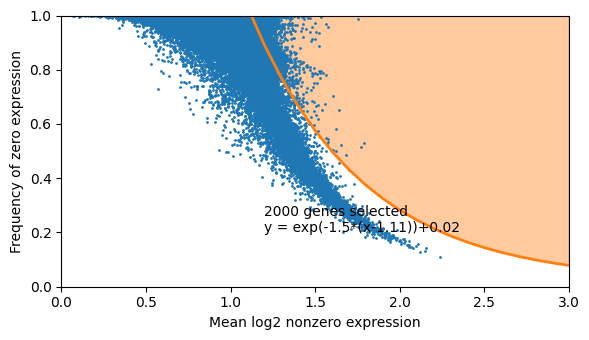

In [ ]:

# ==================== ATAC特征选择函数 ====================
def geneSelection(data, threshold=0, atleast=10,
                 yoffset=0.02, xoffset=5, decay=1.5, n=None,
                 plot=True, markers=None, genes=None, figsize=(6, 3.5),
                 markeroffsets=None, labelsize=10, alpha=1, verbose=1):
    if sp.issparse(data):
        zeroRate = 1 - np.squeeze(np.array((data > threshold).mean(axis=0)))
        A = data.multiply(data > threshold)
        A.data = np.log2(A.data)
        meanExpr = np.zeros_like(zeroRate) * np.nan
        detected = zeroRate < 1
        meanExpr[detected] = np.squeeze(np.array(A[:, detected].mean(axis=0))) / (1 - zeroRate[detected])
    else:
        zeroRate = 1 - np.mean(data > threshold, axis=0)
        meanExpr = np.zeros_like(zeroRate) * np.nan
        detected = zeroRate < 1
        mask = data[:, detected] > threshold
        logs = np.zeros_like(data[:, detected]) * np.nan
        logs[mask] = np.log2(data[:, detected][mask])
        meanExpr[detected] = np.nanmean(logs, axis=0)
    
    lowDetection = np.array(np.sum(data > threshold, axis=0)).squeeze() < atleast
    zeroRate[lowDetection] = np.nan
    meanExpr[lowDetection] = np.nan
    
    if n is not None:
        up = 10
        low = 0
        for t in range(100):
            nonan = ~np.isnan(zeroRate)
            selected = np.zeros_like(zeroRate).astype(bool)
            selected[nonan] = zeroRate[nonan] > np.exp(-decay * (meanExpr[nonan] - xoffset)) + yoffset
            if np.sum(selected) == n:
                break
            elif np.sum(selected) < n:
                up = xoffset
                xoffset = (xoffset + low) / 2
            else:
                low = xoffset
                xoffset = (xoffset + up) / 2
        if verbose > 0:
            print(f'Chosen offset: {xoffset:.2f}')
    else:
        nonan = ~np.isnan(zeroRate)
        selected = np.zeros_like(zeroRate).astype(bool)
        selected[nonan] = zeroRate[nonan] > np.exp(-decay * (meanExpr[nonan] - xoffset)) + yoffset
    
    if verbose > 0:
        print(f'{np.sum(selected)} genes selected\n')
    
    if plot:
        if figsize is not None:
            plt.figure(figsize=figsize)
        plt.ylim([0, 1])
        if threshold > 0:
            plt.xlim([np.log2(threshold), np.ceil(np.nanmax(meanExpr))])
        else:
            plt.xlim([0, np.ceil(np.nanmax(meanExpr))])
        x = np.arange(plt.xlim()[0], plt.xlim()[1] + 0.1, 0.1)
        y = np.exp(-decay * (x - xoffset)) + yoffset
        plt.text(0.4, 0.2, '{} genes selected\ny = exp(-{:.1f}*(x-{:.2f}))+{:.2f}'.format(
            np.sum(selected), decay, xoffset, yoffset),
            color='k', fontsize=labelsize, transform=plt.gca().transAxes)
        plt.plot(x, y, color=sns.color_palette()[1], linewidth=2)
        xy = np.concatenate((np.concatenate((x[:, None], y[:, None]), axis=1),
                           np.array([[plt.xlim()[1], 1]])))
        t = plt.matplotlib.patches.Polygon(xy, color=sns.color_palette()[1], alpha=0.4)
        plt.gca().add_patch(t)
        plt.scatter(meanExpr, zeroRate, s=1, alpha=alpha, rasterized=True)
        if threshold == 0:
            plt.xlabel('Mean log2 nonzero expression')
            plt.ylabel('Frequency of zero expression')
        else:
            plt.xlabel('Mean log2 nonzero expression')
            plt.ylabel('Frequency of near-zero expression')
        plt.tight_layout()
        plt.savefig('select.svg')
    
    return selected

# ================== 模态选择 ==================
# 'multi'  → RNA + ATAC（原始模型）
# 'rna'    → 只用RNA
# 'atac'   → 只用ATAC
MODALITY = 'multi'

# ================== 数据读取模式选择 ==================
# 切换读取模式：
#   'mtx'  → 原始格式（matrix.mtx + features.tsv + barcodes.tsv）
#   'h5ad' → 新格式（rna.h5ad + atac.h5ad + label.csv）
DATA_FORMAT = 'mtx'  # ← 在此切换: 'mtx' 或 'h5ad'
# ================== 选择当前使用的数据集编号 ==================
DATASET_ID = 25   # ← 在此修改数据集编号

# ================== 数据集路径配置 ==================
# ---------- MTX格式数据集 ----------
MTX_DATASETS = {
    # 数据集编号: (数据目录, rna_mtx, rna_features, rna_barcodes, atac_mtx, atac_features, atac_barcodes, label)
    22: (
        "Experiments/22_GSE126074/",
        "brain_SNARE_RNA_matrix.mtx", "brain_SNARE_RNA_features.tsv", "brain_SNARE_barcodes.tsv",
        "brain_SNARE_ATAC_matrix.mtx", "brain_SNARE_ATAC_features.tsv", "brain_SNARE_barcodes.tsv",
        "brain_SNARE_label.csv"
    )
}

# ---------- H5AD格式数据集 ----------
H5AD_DATASETS = {
    # 数据集编号: (数据目录, rna_h5ad文件名, atac_h5ad文件名, label文件名)
    19: (
        "/home/jiaziyu/scNovel-improve/Experiments/19_human_brain_3k/",
        "human_brain_3k_rna.h5ad",
        "human_brain_3k_atac.h5ad",
        "human_brain_3k_label.csv"
    )
}




# ==================== 步骤1: 多模态数据读取 ====================
print("\n" + "="*70)
print("步骤1: 多模态数据读取（RNA + ATAC）")
print("="*70)
print(f"  数据格式: {DATA_FORMAT.upper()}")
print(f"  数据集编号: {DATASET_ID}")

if DATA_FORMAT == 'mtx':
    # -------------------- MTX格式读取 --------------------
    cfg = MTX_DATASETS[DATASET_ID]
    data_dir        = cfg[0]
    rna_mtx         = cfg[1]
    rna_feat_file   = cfg[2]
    rna_bc_file     = cfg[3]
    atac_mtx        = cfg[4]
    atac_feat_file  = cfg[5]
    atac_bc_file    = cfg[6]
    label_file      = cfg[7]

    print("\n[1.1] 读取RNA表达数据（MTX格式）...")
    adata_rna = sc.read_mtx(data_dir + rna_mtx).T
    rna_features = pd.read_csv(data_dir + rna_feat_file, sep='\t', header=None)
    rna_barcodes = pd.read_csv(data_dir + rna_bc_file,   sep='\t', header=None)
    adata_rna.var_names = rna_features[0].values
    adata_rna.obs_names = rna_barcodes[0].values
    print(f"  RNA数据: {adata_rna.shape} (细胞 × 基因)")

    print("\n[1.2] 读取ATAC染色质开放性数据（MTX格式）...")
    adata_atac = sc.read_mtx(data_dir + atac_mtx).T
    atac_features = pd.read_csv(data_dir + atac_feat_file, sep='\t', header=None)
    atac_barcodes = pd.read_csv(data_dir + atac_bc_file,   sep='\t', header=None)
    adata_atac.var_names = atac_features[0].values
    adata_atac.obs_names = atac_barcodes[0].values
    print(f"  ATAC数据: {adata_atac.shape} (细胞 × Peak区域)")

    print("\n[1.3] 读取细胞类型标签...")
    label = pd.read_csv(data_dir + label_file, index_col=0)

elif DATA_FORMAT == 'h5ad':
    # -------------------- H5AD格式读取 --------------------
    cfg = H5AD_DATASETS[DATASET_ID]
    data_dir       = cfg[0]
    rna_h5ad_file  = cfg[1]
    atac_h5ad_file = cfg[2]
    label_file     = cfg[3]

    print("\n[1.1] 读取RNA表达数据（H5AD格式）...")
    adata_rna = sc.read_h5ad(data_dir + rna_h5ad_file)
    # 确保obs_names是字符串类型
    adata_rna.obs_names = adata_rna.obs_names.astype(str)
    print(f"  RNA数据: {adata_rna.shape} (细胞 × 基因)")
    print(f"  RNA obs列: {list(adata_rna.obs.columns)}")
    print(f"  RNA var列: {list(adata_rna.var.columns)}")

    print("\n[1.2] 读取ATAC染色质开放性数据（H5AD格式）...")
    adata_atac = sc.read_h5ad(data_dir + atac_h5ad_file)
    # 确保obs_names是字符串类型
    adata_atac.obs_names = adata_atac.obs_names.astype(str)
    print(f"  ATAC数据: {adata_atac.shape} (细胞 × Peak区域)")
    print(f"  ATAC obs列: {list(adata_atac.obs.columns)}")
    print(f"  ATAC var列: {list(adata_atac.var.columns)}")

    print("\n[1.3] 读取细胞类型标签...")
    label = pd.read_csv(data_dir + label_file, index_col=0)
    # 确保label索引是字符串类型
    label.index = label.index.astype(str)

else:
    raise ValueError(f"不支持的数据格式: {DATA_FORMAT}，请选择 'mtx' 或 'h5ad'")

print(f"  标签数据: {label.shape}")
print(f"  细胞类型: {label.iloc[:, 0].unique()}")
print(f"  各类型数量:\n{label.iloc[:, 0].value_counts()}")

# ==================== 初步对齐 ====================
common_cells = adata_rna.obs_names.intersection(
                   adata_atac.obs_names).intersection(label.index)
print(f"\n[1.4] 初步对齐: {len(common_cells)} 个共同细胞")

if len(common_cells) == 0:
    # 对齐失败时，打印前5个索引帮助排查
    print("⚠️ 对齐失败！请检查索引格式：")
    print(f"  RNA  obs_names 前5个: {list(adata_rna.obs_names[:5])}")
    print(f"  ATAC obs_names 前5个: {list(adata_atac.obs_names[:5])}")
    print(f"  Label index    前5个: {list(label.index[:5])}")
    raise ValueError("三个数据集没有共同细胞，请检查barcode格式是否一致！")

adata_rna  = adata_rna[common_cells, :].copy()
adata_atac = adata_atac[common_cells, :].copy()
label      = label.loc[common_cells, :].copy()


# ==================== 步骤2: RNA预处理 ====================
print("\n" + "="*70)
print("步骤2: RNA数据预处理")
print("="*70)

print(f"预处理前: {adata_rna.n_obs} 个细胞")

sc.pp.filter_cells(adata_rna, min_genes=200)
sc.pp.filter_genes(adata_rna, min_cells=3)
print(f"筛选后: {adata_rna.n_obs} 个细胞（移除了 {len(common_cells) - adata_rna.n_obs} 个低质量细胞）")

sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)

sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000, subset=True)
print(f"特征选择: 保留 {adata_rna.n_vars} 个高变基因")

filtered_cells = adata_rna.obs_names
print(f"\n✓ RNA预处理完成: {len(filtered_cells)} cells × {adata_rna.n_vars} genes")


# ==================== 步骤3: ATAC预处理 ====================
print("\n" + "="*70)
print("步骤3: ATAC数据预处理（特征选择）")
print("="*70)

adata_atac_aligned = adata_atac[filtered_cells, :].copy()
print(f"ATAC对齐后: {adata_atac_aligned.shape}")

if sp.issparse(adata_atac_aligned.X):
    atac_array = adata_atac_aligned.X.toarray()
else:
    atac_array = np.array(adata_atac_aligned.X)

print(f"\n[3.1] 使用geneSelection进行ATAC特征选择...")
print(f"  输入: {atac_array.shape} (细胞 × Peak区域)")

selected_features = geneSelection(
    atac_array,
    threshold=0,
    atleast=10,
    yoffset=0.02,
    xoffset=5,
    decay=1.5,
    n=2000,
    plot=True,
    markers=None,
    genes=None,
    figsize=(6, 3.5),
    verbose=1
)

atac_selected = atac_array[:, selected_features]
print(f"  输出: {atac_selected.shape} (保留了 {np.sum(selected_features)} 个高变Peak)")

print("\n[3.2] ATAC数据标准化...")
from sklearn.preprocessing import normalize

atac_log = np.log1p(atac_selected)
n_cells  = atac_log.shape[0]
idf      = np.log(n_cells / (1 + np.sum(atac_selected > 0, axis=0)))
atac_tfidf      = atac_log * idf
atac_normalized = normalize(atac_tfidf, norm='l2', axis=1)
print(f"  ✓ ATAC标准化完成: {atac_normalized.shape}")


# ==================== 步骤4: Label对齐 ====================
print("\n" + "="*70)
print("步骤4: 根据RNA筛选结果对齐Label")
print("="*70)

label_aligned = label.loc[filtered_cells].copy()
print(f"Label对齐后: {label_aligned.shape}")

assert len(adata_rna) == len(atac_normalized) == len(label_aligned), "数据对齐失败！"
print(f"\n✓ 数据对齐验证通过: {len(filtered_cells)} 个细胞完全对齐")


# ==================== 步骤5: 模态选择 ====================
print("\n" + "="*70)
print("步骤5: 模态选择")
print("="*70)

rna_array = adata_rna.X.toarray() if sp.issparse(adata_rna.X) else np.array(adata_rna.X)

print(f"RNA数据维度:  {rna_array.shape}")
print(f"ATAC数据维度: {atac_normalized.shape}")

# ---------- 多模态 ----------
if MODALITY == 'multi':
    fused_array = np.hstack([rna_array, atac_normalized])

    rna_columns  = [f"RNA_{i}" for i in range(rna_array.shape[1])]
    atac_columns = [f"ATAC_{i}" for i in range(atac_normalized.shape[1])]
    all_columns  = rna_columns + atac_columns

    print("\n✓ 使用 RNA + ATAC 多模态")

# ---------- RNA-only ----------
elif MODALITY == 'rna':
    fused_array = rna_array

    all_columns = [f"RNA_{i}" for i in range(rna_array.shape[1])]

    print("\n✓ 使用 RNA 单模态")

# ---------- ATAC-only ----------
elif MODALITY == 'atac':
    fused_array = atac_normalized

    all_columns = [f"ATAC_{i}" for i in range(atac_normalized.shape[1])]

    print("\n✓ 使用 ATAC 单模态")

else:
    raise ValueError("MODALITY 必须是 'multi'、'rna' 或 'atac'")

print(f"\n最终特征维度: {fused_array.shape}")

data = pd.DataFrame(
    fused_array,
    index=filtered_cells,
    columns=all_columns
)

print(f"\n最终数据:")
print(f"  特征矩阵: {data.shape}")
print(f"  标签:     {label_aligned.shape}")




In [10]:
import pandas as pd

label = pd.read_csv("/home/jiaziyu/scNovel-improve/Experiments/25_pbmc_granulocyte_sorted_10k/pbmc_granulocyte_sorted_10k_label.csv", index_col=0)
print(label.head())

                    cell_type
AAACAGCCAATCCCTT-1          2
AAACAGCCAATGCGCT-1          3
AAACAGCCACCAACCG-1          1
AAACAGCCAGGATAAC-1          3
AAACAGCCAGTTTACG-1          2


In [6]:
# ==================== 步骤6: 数据集划分 ====================
print("\n" + "="*70)
print("步骤6: 数据集划分（正常细胞 vs 稀有细胞）")
print("="*70)

def build_dataset(data, label, drop_number=1):
    """
    划分数据集：
    1. 找到细胞数最少的 drop_number 个类型作为稀有细胞（OOD）
    2. 剩余细胞作为正常细胞（ID）
    3. 正常细胞中样本不足5个的类别也移入OOD
    4. 正常细胞按8:2划分训练集和测试集
    5. 最终测试集 = 20%正常细胞 + 100%稀有细胞
    """
    label_col = label.columns[0]
    counts    = label[label_col].value_counts()

    print(f"\n各细胞类型数量:")
    print(counts.to_string())

    # 找到最少的drop_number个类型作为稀有细胞
    rare_types = counts.nsmallest(drop_number).index.tolist()
    print(f"\n稀有细胞类型: {rare_types}")
    print(f"稀有细胞数量: {[counts[rt] for rt in rare_types]}")

    is_rare = label[label_col].isin(rare_types)
    X_ood   = data.loc[is_rare]
    y_ood   = label.loc[is_rare]
    X_id    = data.loc[~is_rare]
    y_id    = label.loc[~is_rare]

    print(f"\n正常细胞: {len(X_id)} 个")
    print(f"稀有细胞: {len(X_ood)} 个")

    # 将样本数不足5个的类别也移入OOD（循环直到无问题类别）
    while True:
        id_counts   = y_id[label_col].value_counts()
        # test_size=0.2 → 每类至少需要 ceil(1/0.2)=5 个样本
        problematic = id_counts[id_counts < 5].index.tolist()

        if len(problematic) == 0:
            break

        print(f"\n以下类别样本不足5个，移入稀有细胞集合: {problematic}")

        is_problematic = y_id[label_col].isin(problematic)
        X_ood = pd.concat([X_ood, X_id.loc[is_problematic]])
        y_ood = pd.concat([y_ood, y_id.loc[is_problematic]])
        X_id  = X_id.loc[~is_problematic]
        y_id  = y_id.loc[~is_problematic]

        print(f"调整后 → 正常细胞: {len(X_id)} 个, 稀有细胞: {len(X_ood)} 个")

    # 按8:2划分
    X_train, X_test_id, y_train, y_test_id = train_test_split(
        X_id, y_id,
        test_size=0.2,
        random_state=42,
        stratify=y_id
    )

    print(f"\n✅ 数据划分完成:")
    print(f"  训练集: {len(X_train)} 个正常细胞")
    print(f"  测试集: {len(X_test_id)} 个正常细胞 + {len(X_ood)} 个稀有细胞")

    return X_train, X_test_id, y_train, y_test_id, X_ood, y_ood


X_train, X_test_id, y_train, y_test_id, X_ood, y_ood = build_dataset(
    data, label_aligned, drop_number=1
)

# 合并测试集
test_all   = pd.concat([X_test_id, X_ood], axis=0)
true_label = np.concatenate([
    np.ones(len(X_test_id)),  
    np.zeros(len(X_ood))      
])

print(f"\n✓ 最终测试集: {len(test_all)} 个细胞")
print(f"  - 其它细胞类型: {len(X_test_id)} (标签=0)")
print(f"  - 数量最少的细胞类型: {len(X_ood)} (标签=1)")


步骤6: 数据集划分（正常细胞 vs 稀有细胞）

各细胞类型数量:
cell_type
0     2682
1     1434
2     1132
3     1029
4      516
5      508
6      449
7      448
8      436
9      388
10     332
11     173
12     156
13     123
14     120
15     115
16      96

稀有细胞类型: [16]
稀有细胞数量: [96]

正常细胞: 10041 个
稀有细胞: 96 个

✅ 数据划分完成:
  训练集: 8032 个正常细胞
  测试集: 2009 个正常细胞 + 96 个稀有细胞

✓ 最终测试集: 2105 个细胞
  - 其它细胞类型: 2009 (标签=0)
  - 数量最少的细胞类型: 96 (标签=1)


In [ ]:
# ==================== 步骤7: 模型训练 ====================
print("\n" + "="*70)
print("步骤7: 训练注意力模型 + Mahalanobis+Energy评分")
print("="*70)

import sys
sys.path.insert(0, '/home')
import scMORCEL as sr

import time

# ====== 开始计时 ======
total_start_time = time.time()

test_score, history = sr.scMORCEL(
    test=test_all,
    reference=X_train,
    label=y_train,
    processing_unit='cuda',
    max_epochs=150,
    patience=25,
    model_type='attention',
    #model_type='basic',
    attention_heads=4,
    score_function='mahalanobis_energy',
    mahal_energy_alpha=0.7,
    energy_temperature=1.0,
    use_validation=True,
    validation_split=0.2,
    learning_rate=5e-4,
    use_contrastive=True,
    contrastive_weight=0.03,
    contrastive_temperature=0.6,
    contrastive_type='contrastive',
    verbose=True
)

total_end_time = time.time()

total_seconds = total_end_time - total_start_time


步骤7: 训练注意力模型 + Mahalanobis+Energy评分
开始数据预处理
训练集样本数: 6425
验证集样本数: 1607
测试集样本数: 2105

模型配置:
  - 输入特征数: 4000
  - 类别数: 16
  - 模型类型: attention
  - 使用多头注意力分类器 (heads=4)
  ✓ 启用监督对比学习损失
    - 权重: 0.03
    - 温度: 0.6
  - 计算设备: cuda

开始训练
Epoch   1/150 | Total: 1.1953 | Val: 0.8661 | CE: 0.6309 | Contrast: 18.8119 | LR: 0.000500
Epoch   5/150 | Total: 0.5366 | Val: 0.8748 | CE: 0.0478 | Contrast: 16.2918 | LR: 0.000500
Epoch  10/150 | Total: 0.4844 | Val: 0.9103 | CE: 0.0154 | Contrast: 15.6309 | LR: 0.000500
Epoch 00015: reducing learning rate of group 0 to 2.5000e-04.
Epoch  15/150 | Total: 0.4628 | Val: 1.0043 | CE: 0.0067 | Contrast: 15.2021 | LR: 0.000250
Epoch  20/150 | Total: 0.4491 | Val: 1.0222 | CE: 0.0014 | Contrast: 14.9239 | LR: 0.000250
Epoch  25/150 | Total: 0.4511 | Val: 1.0564 | CE: 0.0043 | Contrast: 14.8933 | LR: 0.000250

早停触发 (epoch 27)
  - 验证loss连续 25 轮未改善
  - 最佳验证loss: 0.8451

✓ 已加载最佳模型 (验证loss: 0.8451)

训练完成! 总耗时: 173.56 秒

开始OOD评分 (方法: mahalanobis_energy)...

组合Mahalanob

In [8]:
# ==================== 步骤8: 评估结果 ====================
print("\n" + "="*70)
print("步骤8: 评估罕见细胞检测性能")
print("="*70)

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, roc_curve)

auroc = roc_auc_score(true_label, test_score)
aupr  = average_precision_score(true_label, test_score)


fpr, tpr, thresholds = roc_curve(true_label, test_score)
idx   = np.argmin(np.abs(tpr - 0.95))
fpr95 = fpr[idx]

print(f"\nAUROC:   {auroc:.4f}")
print(f"AUPR:    {aupr:.4f}")
print(f"FPR95:   {fpr95:.4f}")
print(f"总时间: {total_seconds:.2f} 秒")


步骤8: 评估罕见细胞检测性能

AUROC:   0.9841
AUPR:    0.9991
FPR95:   0.0104
总时间: 181.68 秒
